# Late Fusion Model for Outcome Classification (No Temporal Behavior Features)

This notebook implements late fusion combining:
- **Physiological data** (pupil metrics)
- **Behavioral data** (WITHOUT reaction_time, decision_time, ambiguity)
- **Gaze data** (gaze position, movements, fixations)

**Note**: This version excludes reaction_time, decision_time, and ambiguity from behavioral features.

**Parameterized**: Set `TIMEFRAME` to run PRE or POST analysis.

Goals:
1. Train separate models for each modality
2. Implement late fusion (stacking/weight averaging)
3. Extract weights to estimate modality influence on predictions

In [1]:
# ============================================================================
# CONFIGURATION: Set timeframe for analysis
# ============================================================================
TIMEFRAME = 'PRE'  # Options: 'PRE', 'POST'
# ============================================================================

import sys
sys.path.append('../..')  # Add project root to path

import json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Import from src package
from src.utils.io import load_features, save_results
from src.utils.config import get_model_params, load_config
from src.utils.validation import validate_features, validate_modality_features
from src.models.fusion import weighted_late_fusion
from src.visualization.plots import (
    plot_method_comparison,
    plot_modality_weights,
    set_style
)

np.random.seed(42)
set_style('whitegrid')  # Use shared style function

print(f"\n{'='*70}")
print(f"LATE FUSION ANALYSIS (NO TEMPORAL BEHAVIOR): {TIMEFRAME}-DECISION PERIOD")
print(f"Excluded behavior features: reaction_time, decision_time, ambiguity")
print(f"{'='*70}\n")


LATE FUSION ANALYSIS (NO TEMPORAL BEHAVIOR): PRE-DECISION PERIOD
Excluded behavior features: reaction_time, decision_time, ambiguity



## 1. Load Pre-Extracted Features

In [2]:
# Load configuration
config = load_config('model_params')
time_window = config['time_windows'][f'{TIMEFRAME.lower()}_decision']

print(f"Time window: {time_window['start']}s to {time_window['end']}s")
print(f"Description: {time_window['description']}\n")

# Load pre-extracted features
features_path = f'../../data/features/extracted_features_{TIMEFRAME}.pkl'
feature_data = load_features(features_path, timeframe=TIMEFRAME)

merged_df = feature_data['merged_df']
physio_cols = feature_data['physio_cols']
behavior_cols_original = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']

# EXCLUDE reaction_time, decision_time, and ambiguity from behavior features
excluded_features = ['reaction_time', 'decision_time', 'ambiguity']
behavior_cols = [col for col in behavior_cols_original if col not in excluded_features]

print(f"Original behavior features: {behavior_cols_original}")
print(f"Excluded features: {excluded_features}")
print(f"Remaining behavior features: {behavior_cols}")

# Validate loaded features
validate_features(merged_df, timeframe=TIMEFRAME)

print(f"  Features extracted on: {feature_data['metadata']['extraction_date']}")
if 'baseline_method' in feature_data['metadata']:
    print(f"  Baseline method: {feature_data['metadata']['baseline_method']}")
print(f"\nFeature counts:")
print(f"  Physiology ({TIMEFRAME}): {len(physio_cols)} features")
print(f"  Behavior (filtered): {len(behavior_cols)} features")
print(f"  Gaze: {len(gaze_cols)} features")

Time window: -2.0s to 0.0s
Description: Anticipatory period before submit button

Original behavior features: ['reaction_time', 'decision_time', 'ev_difference', 'invest_variance', 'ambiguity', 'condition_social', 'risk_premium']
Excluded features: ['reaction_time', 'decision_time', 'ambiguity']
Remaining behavior features: ['ev_difference', 'invest_variance', 'condition_social', 'risk_premium']
✓ Validation passed (PRE): 12511 trials, 97 subjects
  Trials per subject: min=9, max=246, mean=129.0
  Outcome balance: 4273 keep / 8238 invest
  Features extracted on: 2026-01-10 14:16:16
  Baseline method: t3_stable_pre_decision

Feature counts:
  Physiology (PRE): 13 features
  Behavior (filtered): 4 features
  Gaze: 20 features


## 2. Prepare Feature Sets

In [3]:
# Prepare feature arrays for model training
X_physio = SimpleImputer(strategy='mean').fit_transform(merged_df[physio_cols])
X_behavior = SimpleImputer(strategy='mean').fit_transform(merged_df[behavior_cols])

# Handle gaze features (may be empty in POST)
if len(gaze_cols) > 0:
    X_gaze = SimpleImputer(strategy='mean').fit_transform(merged_df[gaze_cols])
else:
    # Create placeholder array for POST condition (no gaze data)
    X_gaze = np.zeros((len(merged_df), 1))

y = merged_df['outcome'].values
subjects = merged_df['subject_id'].values

print(f"Shapes: X_physio={X_physio.shape}, X_behavior={X_behavior.shape}, X_gaze={X_gaze.shape}")

Shapes: X_physio=(12511, 13), X_behavior=(12511, 4), X_gaze=(12511, 20)


In [4]:
def train_evaluate_modality(X, y, subjects, modality_name):
    """
    Train and evaluate a single modality using LOSO cross-validation.
    
    Parameters
    ----------
    X : np.ndarray
        Feature matrix for the modality, shape (n_samples, n_features)
    y : np.ndarray
        Target labels, shape (n_samples,)
    subjects : np.ndarray
        Subject IDs for each sample, shape (n_samples,)
    modality_name : str
        Name of the modality (for display purposes)
    
    Returns
    -------
    tuple
        (model, accuracy, f1_score, predictions, y_true)
        - model: Last trained RandomForestClassifier
        - accuracy: Mean accuracy across subjects
        - f1_score: Mean F1-score across subjects
        - predictions: All predictions concatenated
        - y_true: All true labels concatenated
    """
    logo = LeaveOneGroupOut()
    
    # Get model parameters from config
    model_params = get_model_params('random_forest')
    
    # Initialize storage
    all_preds = []
    all_y_true = []
    subject_accs = []
    subject_f1s = []
    
    print(f"\n{'='*50}")
    print(f"{modality_name} Model")
    print(f"{'='*50}")
    
    # LOSO cross-validation
    for train_idx, test_idx in logo.split(X, y, subjects):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Train model
        model = RandomForestClassifier(**model_params)
        model.fit(X_train, y_train)
        
        # Predict
        y_pred = model.predict(X_test)
        
        # Store results
        all_preds.extend(y_pred)
        all_y_true.extend(y_test)
        
        # Subject-level metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        subject_accs.append(acc)
        subject_f1s.append(f1)
    
    # Calculate overall metrics
    overall_acc = np.mean(subject_accs)
    overall_f1 = np.mean(subject_f1s)
    
    print(f"Accuracy: {overall_acc:.3f} +/- {stats.sem(subject_accs):.3f}")
    print(f"F1-Score: {overall_f1:.3f} +/- {stats.sem(subject_f1s):.3f}")
    print(f"N subjects: {len(subject_accs)}")
    
    return model, overall_acc, overall_f1, np.array(all_preds), np.array(all_y_true)

## 3. Train Individual Modality Models

In [5]:
model_physio, acc_physio, f1_physio, pred_physio, y_true = train_evaluate_modality(
    X_physio, y, subjects, "Physiology"
)
model_behavior, acc_behavior, f1_behavior, pred_behavior, _ = train_evaluate_modality(
    X_behavior, y, subjects, "Behavior (No Temporal)"
)

# Only train gaze model if gaze data exists
if len(gaze_cols) > 0:
    model_gaze, acc_gaze, f1_gaze, pred_gaze, _ = train_evaluate_modality(
        X_gaze, y, subjects, "Gaze"
    )
else:
    # Placeholder for POST (no gaze data)
    model_gaze = None
    acc_gaze = 0.5
    f1_gaze = 0.5
    pred_gaze = np.zeros(len(y))
    print(f"\n{'='*50}\nGaze Model\n{'='*50}")
    print("Skipping - no gaze data available (POST condition)")


Physiology Model
Accuracy: 0.519 +/- 0.014
F1-Score: 0.504 +/- 0.017
N subjects: 97

Behavior (No Temporal) Model
Accuracy: 0.483 +/- 0.013
F1-Score: 0.503 +/- 0.011
N subjects: 97

Gaze Model
Accuracy: 0.503 +/- 0.012
F1-Score: 0.505 +/- 0.014
N subjects: 97


## 4. Late Fusion Implementation

Using shared `weighted_late_fusion` function from `src.models.fusion`.

In [7]:
# Run fusion methods
if len(gaze_cols) > 0:
    X_modalities = [X_physio, X_behavior, X_gaze]
    modality_names = ['Physiology', 'Behavior', 'Gaze']
else:
    # POST condition: no gaze data
    X_modalities = [X_physio, X_behavior]
    modality_names = ['Physiology', 'Behavior']

# Validate modalities before fusion
validate_modality_features(X_modalities, y, subjects, modality_names)

print("\nRunning fusion methods...")
results_avg = weighted_late_fusion(X_modalities, y, subjects, modality_names,
                                   fusion_method='average')
results_weighted = weighted_late_fusion(X_modalities, y, subjects, modality_names,
                                        fusion_method='weighted')
results_stacking = weighted_late_fusion(X_modalities, y, subjects, modality_names,
                                        fusion_method='stacking')

✓ Modality validation passed:
  Physiology: 12511 samples × 13 features
  Behavior: 12511 samples × 4 features
  Gaze: 12511 samples × 20 features

Running fusion methods...


## 5. Compare All Methods


PERFORMANCE COMPARISON (PRE) - NO TEMPORAL BEHAVIOR FEATURES
                     Method  Accuracy  F1-Score
            Physiology Only  0.519080  0.504044
Behavior Only (No Temporal)  0.483426  0.503326
                  Gaze Only  0.502747  0.504944
             Average Fusion  0.558673  0.567300
            Weighted Fusion  0.656061  0.535853
                   Stacking  0.557057  0.574421


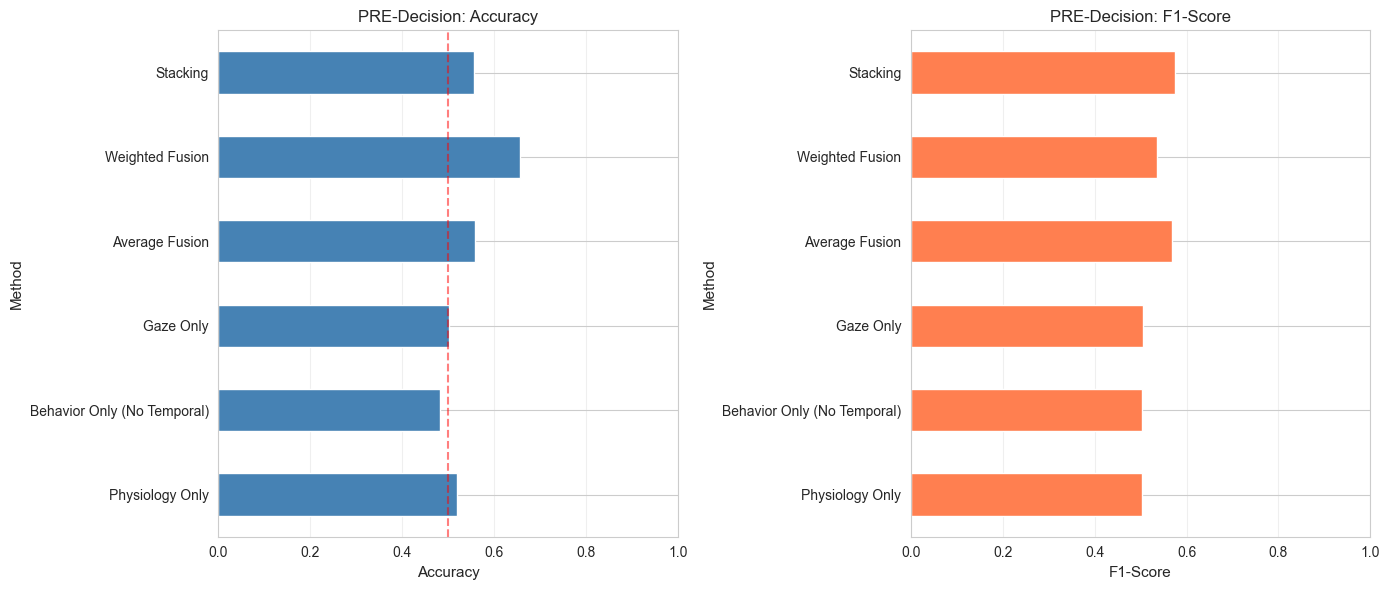

In [8]:
# Build comparison dataframe
comparison_data = {
    'Method': ['Physiology Only', 'Behavior Only (No Temporal)'],
    'Accuracy': [acc_physio, acc_behavior],
    'F1-Score': [f1_physio, f1_behavior]
}

# Add gaze if available
if len(gaze_cols) > 0:
    comparison_data['Method'].append('Gaze Only')
    comparison_data['Accuracy'].append(acc_gaze)
    comparison_data['F1-Score'].append(f1_gaze)

# Add fusion methods
comparison_data['Method'].extend(['Average Fusion', 'Weighted Fusion', 'Stacking'])
comparison_data['Accuracy'].extend([
    results_avg['accuracy_mean'],
    results_weighted['accuracy_mean'],
    results_stacking['accuracy_mean']
])
comparison_data['F1-Score'].extend([
    results_avg['f1_mean'],
    results_weighted['f1_mean'],
    results_stacking['f1_mean']
])

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*70)
print(f"PERFORMANCE COMPARISON ({TIMEFRAME}) - NO TEMPORAL BEHAVIOR FEATURES")
print("="*70)
print(comparison_df.to_string(index=False))

# Use shared plotting function
fig = plot_method_comparison(comparison_df, timeframe=TIMEFRAME)
plt.show()

## 6. Summary

In [9]:
print("\n" + "="*70)
print(f"SUMMARY ({TIMEFRAME}-DECISION) - NO TEMPORAL BEHAVIOR FEATURES")
print(f"Excluded: reaction_time, decision_time, ambiguity")
print("="*70)

print("\n1. INDIVIDUAL MODALITIES:")
print(f"   Physiology:  Acc={acc_physio:.3f}, F1={f1_physio:.3f}")
print(f"   Behavior:    Acc={acc_behavior:.3f}, F1={f1_behavior:.3f}")
if len(gaze_cols) > 0:
    print(f"   Gaze:        Acc={acc_gaze:.3f}, F1={f1_gaze:.3f}")
else:
    print(f"   Gaze:        Not available (POST condition)")

print("\n2. LATE FUSION METHODS:")
print(f"   Average:     Acc={results_avg['accuracy_mean']:.3f}, F1={results_avg['f1_mean']:.3f}")
print(f"   Weighted:    Acc={results_weighted['accuracy_mean']:.3f}, F1={results_weighted['f1_mean']:.3f}")
print(f"   Stacking:    Acc={results_stacking['accuracy_mean']:.3f}, F1={results_stacking['f1_mean']:.3f}")

print("\n3. MODALITY CONTRIBUTIONS (Weighted Fusion):")
for name, w in zip(modality_names, results_weighted['weights']):
    print(f"   {name:12s}: {w*100:5.1f}%")

best = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
print(f"\n4. BEST METHOD: {best['Method']} (Acc={best['Accuracy']:.3f})")
print("\n" + "="*70)


SUMMARY (PRE-DECISION) - NO TEMPORAL BEHAVIOR FEATURES
Excluded: reaction_time, decision_time, ambiguity

1. INDIVIDUAL MODALITIES:
   Physiology:  Acc=0.519, F1=0.504
   Behavior:    Acc=0.483, F1=0.503
   Gaze:        Acc=0.503, F1=0.505

2. LATE FUSION METHODS:
   Average:     Acc=0.559, F1=0.567
   Weighted:    Acc=0.656, F1=0.536
   Stacking:    Acc=0.557, F1=0.574

3. MODALITY CONTRIBUTIONS (Weighted Fusion):
   Physiology  :  52.3%
   Behavior    :  45.8%
   Gaze        :   1.9%

4. BEST METHOD: Weighted Fusion (Acc=0.656)



## 7. Modality Weights Visualization


MODALITY WEIGHTS (Influence on Prediction)
  Modality  Average  Weighted  Stacking
Physiology 0.333333  0.523311  0.476079
  Behavior 0.333333  0.457707  0.369008
      Gaze 0.333333  0.018982  0.154913


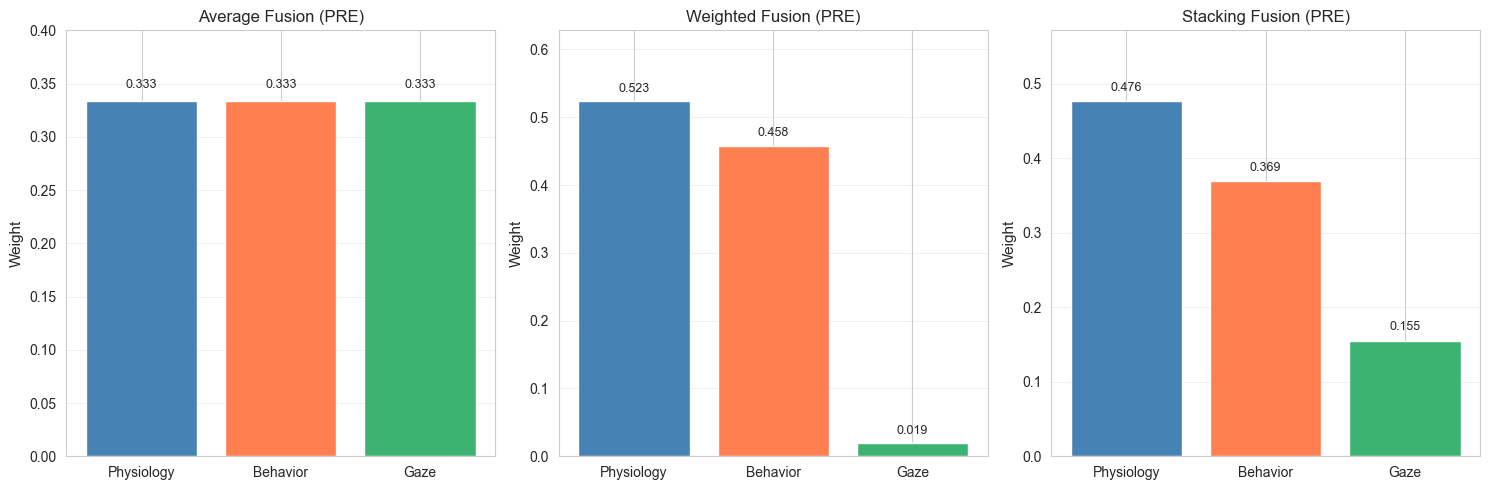

In [10]:
weights_df = pd.DataFrame({
    'Modality': modality_names,
    'Average': results_avg['weights'],
    'Weighted': results_weighted['weights'],
    'Stacking': results_stacking['weights']
})

print("\n" + "="*50)
print("MODALITY WEIGHTS (Influence on Prediction)")
print("="*50)
print(weights_df.to_string(index=False))

# Use shared plotting function
fig = plot_modality_weights(weights_df, timeframe=TIMEFRAME)
plt.show()

## 8. Save Results

In [11]:
# Save results using shared utility
import os
output_dir = f'../../data/results/main/late_fusion/fusion_model_results_no_temporal_{TIMEFRAME}'
os.makedirs(output_dir, exist_ok=True)

# 1. Save method comparison results
save_results(comparison_df, 
             f'{output_dir}/late_fusion_model_no_temporal_{TIMEFRAME}_method_comparison.csv')

# 2. Save modality weights
save_results(weights_df,
             f'{output_dir}/late_fusion_model_no_temporal_{TIMEFRAME}_modality_weights.csv')

# 3. Save weighted fusion summary
weighted_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Accuracy_SEM', 'F1_Score', 'F1_SEM', 'N_Subjects', 'N_Trials'],
    'Value': [
        results_weighted['accuracy_mean'],
        results_weighted['accuracy_sem'],
        results_weighted['f1_mean'],
        results_weighted['f1_sem'],
        results_weighted['n_subjects'],
        results_weighted['n_trials']
    ]
})
save_results(weighted_summary,
             f'{output_dir}/late_fusion_model_no_temporal_{TIMEFRAME}_weighted_fusion_summary.csv')

# 4. Save subject-level accuracies
subject_df = pd.DataFrame({
    'subject_id': list(results_weighted['subject_accs'].keys()),
    'accuracy': list(results_weighted['subject_accs'].values())
})
save_results(subject_df,
             f'{output_dir}/late_fusion_model_no_temporal_{TIMEFRAME}_subject_accuracies.csv')
print(f"  - {len(subject_df)} subjects, Mean accuracy: {subject_df['accuracy'].mean():.4f}")

# 5. Save excluded features info
excluded_info = pd.DataFrame({
    'excluded_feature': excluded_features,
    'reason': ['temporal/grouping variable'] * len(excluded_features)
})
save_results(excluded_info,
             f'{output_dir}/late_fusion_model_no_temporal_{TIMEFRAME}_excluded_features.csv')

print(f"\nAll results saved to: {output_dir}/")

✓ Saved results to: ../../data/results/main/late_fusion/fusion_model_results_no_temporal_PRE/late_fusion_model_no_temporal_PRE_method_comparison.csv
✓ Saved results to: ../../data/results/main/late_fusion/fusion_model_results_no_temporal_PRE/late_fusion_model_no_temporal_PRE_modality_weights.csv
✓ Saved results to: ../../data/results/main/late_fusion/fusion_model_results_no_temporal_PRE/late_fusion_model_no_temporal_PRE_weighted_fusion_summary.csv
✓ Saved results to: ../../data/results/main/late_fusion/fusion_model_results_no_temporal_PRE/late_fusion_model_no_temporal_PRE_subject_accuracies.csv
  - 97 subjects, Mean accuracy: 0.6561
✓ Saved results to: ../../data/results/main/late_fusion/fusion_model_results_no_temporal_PRE/late_fusion_model_no_temporal_PRE_excluded_features.csv

All results saved to: ../../data/results/main/late_fusion/fusion_model_results_no_temporal_PRE/


## 9. Feature Importance Analysis (SHAP)

Compute SHAP values for each modality to identify which specific features drive predictions.

In [12]:
import shap

def train_and_get_shap(X, y, subjects, feature_names, model_name="Model"):
    """
    Train RF model with LOSO CV and compute SHAP values.
    
    Returns:
    - shap_values: SHAP values for all test samples
    - feature_importance_df: DataFrame with feature importance scores
    - X_test_ordered: Test samples in order matching SHAP values
    """
    print(f"\n{'='*60}")
    print(f"Computing SHAP values for {model_name}")
    print(f"{'='*60}")
    
    logo = LeaveOneGroupOut()
    
    # Store SHAP values for all test samples
    all_shap_values = []
    all_test_indices = []
    
    # Model parameters (same as in late fusion)
    model_params = get_model_params('random_forest')
    
    # LOSO cross-validation
    fold_count = 0
    for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, subjects)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train = y[train_idx]
        
        # Train model
        rf = RandomForestClassifier(**model_params)
        rf.fit(X_train, y_train)
        
        # Compute SHAP values for this fold
        explainer = shap.TreeExplainer(rf)
        shap_values_fold = explainer.shap_values(X_test)
        
        # Handle different SHAP output formats
        if isinstance(shap_values_fold, list):
            # Binary classification - take class 1 (INVEST)
            shap_values_fold = shap_values_fold[1]
        
        # If still 3D (samples, features, classes), take the last dimension
        if len(shap_values_fold.shape) == 3:
            shap_values_fold = shap_values_fold[:, :, 1]
        
        # Ensure 2D array
        if len(shap_values_fold.shape) == 1:
            shap_values_fold = shap_values_fold.reshape(1, -1)
        
        all_shap_values.append(shap_values_fold)
        all_test_indices.extend(test_idx)
        
        fold_count += 1
        if fold_count % 20 == 0:
            print(f"  Processed {fold_count} folds...")
    
    # Concatenate all SHAP values
    shap_values_array = np.vstack(all_shap_values)
    
    # Compute mean absolute SHAP values for each feature
    mean_abs_shap = np.abs(shap_values_array).mean(axis=0)
    
    # Ensure mean_abs_shap is 1D
    if len(mean_abs_shap.shape) > 1:
        mean_abs_shap = mean_abs_shap.flatten()
    
    # Create feature importance DataFrame
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'mean_abs_shap': mean_abs_shap
    }).sort_values('mean_abs_shap', ascending=False)
    
    print(f"\n✓ SHAP computation complete for {model_name}")
    print(f"  Total samples: {shap_values_array.shape[0]}")
    print(f"  Total features: {shap_values_array.shape[1]}")
    
    return shap_values_array, feature_importance_df, X[all_test_indices]

In [13]:
# Compute SHAP values for each modality
print("Computing SHAP feature importance for each modality...")
print("(This may take a few minutes due to LOSO cross-validation)\n")

# 1. Physiology
shap_values_phys, importance_phys, X_test_phys = train_and_get_shap(
    X_physio, y, subjects, physio_cols, "Physiology"
)

print("\nTop 10 Physiology Features:")
print(importance_phys.head(10).to_string(index=False))

Computing SHAP feature importance for each modality...
(This may take a few minutes due to LOSO cross-validation)


Computing SHAP values for Physiology
  Processed 20 folds...
  Processed 40 folds...
  Processed 60 folds...
  Processed 80 folds...

✓ SHAP computation complete for Physiology
  Total samples: 12511
  Total features: 13

Top 10 Physiology Features:
                        feature  mean_abs_shap
                pupil_slope_pre       0.033265
                  pupil_std_pre       0.017106
          pct_time_dilating_pre       0.012250
               time_to_peak_pre       0.011671
                   pupil_cv_pre       0.007989
    pupil_max_dilation_rate_pre       0.005082
        pupil_velocity_mean_pre       0.004041
pupil_max_constriction_rate_pre       0.003593
              eye_asymmetry_pre       0.003235
                 pupil_mean_pre       0.003147


In [14]:
# 2. Behavior (No Temporal)
shap_values_behavior, importance_behavior, X_test_behavior = train_and_get_shap(
    X_behavior, y, subjects, behavior_cols, "Behavior (No Temporal)"
)

print("\nAll Behavior Features (No Temporal):")
print(importance_behavior.to_string(index=False))


Computing SHAP values for Behavior (No Temporal)
  Processed 20 folds...
  Processed 40 folds...
  Processed 60 folds...
  Processed 80 folds...

✓ SHAP computation complete for Behavior (No Temporal)
  Total samples: 12511
  Total features: 4

All Behavior Features (No Temporal):
         feature  mean_abs_shap
 invest_variance       0.019000
   ev_difference       0.016708
    risk_premium       0.013571
condition_social       0.003257


In [15]:
# 3. Gaze (if available)
if len(gaze_cols) > 0:
    shap_values_gaze, importance_gaze, X_test_gaze = train_and_get_shap(
        X_gaze, y, subjects, gaze_cols, "Gaze"
    )
    print("\nTop 10 Gaze Features:")
    print(importance_gaze.head(10).to_string(index=False))
else:
    importance_gaze = None
    print("Gaze features not available (POST condition)")


Computing SHAP values for Gaze
  Processed 20 folds...
  Processed 40 folds...
  Processed 60 folds...
  Processed 80 folds...

✓ SHAP computation complete for Gaze
  Total samples: 12511
  Total features: 20

Top 10 Gaze Features:
               feature  mean_abs_shap
      gaze_path_length       0.015481
         screen_y_mean       0.009738
     gaze_dispersion_y       0.006673
           gaze_y_mean       0.005527
            gaze_y_std       0.005171
     gaze_dispersion_x       0.005036
gaze_acceleration_mean       0.004864
 gaze_acceleration_std       0.004646
           gaze_x_mean       0.004410
    gaze_velocity_mean       0.004184


In [16]:
# 4. All Features Combined (Physiology + Behavior + Gaze)
all_feature_cols = physio_cols + behavior_cols + (gaze_cols if len(gaze_cols) > 0 else [])
X_all = np.hstack([X_physio, X_behavior] + ([X_gaze] if len(gaze_cols) > 0 else []))

shap_values_all, importance_all, X_test_all = train_and_get_shap(
    X_all, y, subjects, all_feature_cols, "All Features (No Temporal Behavior)"
)

print("\nTop 15 Features (All Modalities Combined):")
print(importance_all.head(15).to_string(index=False))


Computing SHAP values for All Features (No Temporal Behavior)
  Processed 20 folds...
  Processed 40 folds...
  Processed 60 folds...
  Processed 80 folds...

✓ SHAP computation complete for All Features (No Temporal Behavior)
  Total samples: 12511
  Total features: 37

Top 15 Features (All Modalities Combined):
                    feature  mean_abs_shap
            pupil_slope_pre       0.028056
              pupil_std_pre       0.017909
               risk_premium       0.011911
              ev_difference       0.011428
            invest_variance       0.011416
      pct_time_dilating_pre       0.008642
           time_to_peak_pre       0.007922
               pupil_cv_pre       0.005936
              screen_y_mean       0.004616
                gaze_y_mean       0.003759
    pupil_velocity_mean_pre       0.003252
                 gaze_x_std       0.002899
pupil_max_dilation_rate_pre       0.002877
                gaze_x_mean       0.002508
                 gaze_y_std       0.002

## 10. Feature Importance Visualization

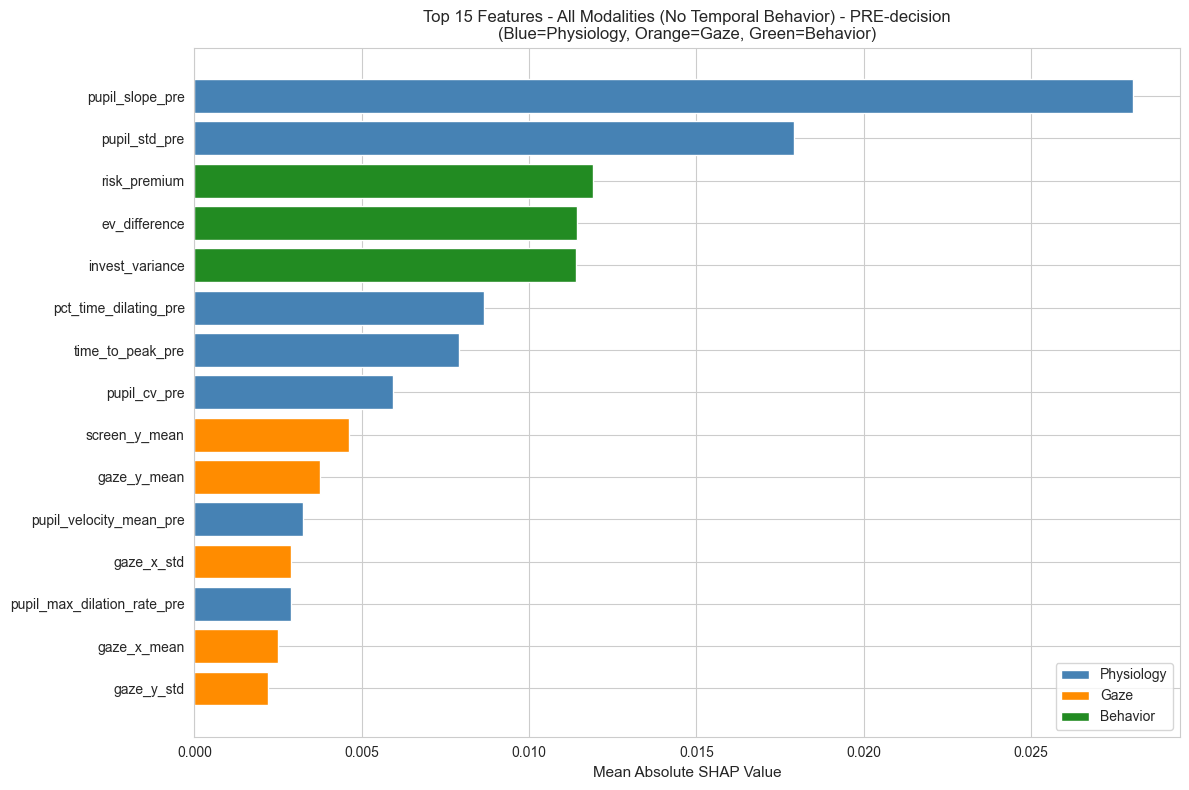

In [17]:
# Helper function to get modality color
def get_modality_color(feature):
    if feature in physio_cols:
        return 'steelblue'
    elif feature in behavior_cols:
        return 'forestgreen'
    elif feature in gaze_cols:
        return 'darkorange'
    return 'gray'

def get_modality_name(feature):
    if feature in physio_cols:
        return 'Physiology'
    elif feature in behavior_cols:
        return 'Behavior'
    elif feature in gaze_cols:
        return 'Gaze'
    return 'Unknown'

# Plot top 15 features across all modalities
fig, ax = plt.subplots(figsize=(12, 8))
top_15_all = importance_all.head(15)
colors = [get_modality_color(f) for f in top_15_all['feature']]

ax.barh(range(len(top_15_all)), top_15_all['mean_abs_shap'], color=colors)
ax.set_yticks(range(len(top_15_all)))
ax.set_yticklabels(top_15_all['feature'])
ax.invert_yaxis()
ax.set_xlabel('Mean Absolute SHAP Value')
ax.set_title(f'Top 15 Features - All Modalities (No Temporal Behavior) - {TIMEFRAME}-decision\n(Blue=Physiology, Orange=Gaze, Green=Behavior)')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Physiology'),
    Patch(facecolor='darkorange', label='Gaze'),
    Patch(facecolor='forestgreen', label='Behavior')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(f'{output_dir}/shap_all_top15_no_temporal_{TIMEFRAME}.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# Print formatted summary
print("\n" + "="*70)
print(f"TOP 10 FEATURES DRIVING {TIMEFRAME}-DECISION PREDICTIONS")
print(f"(No Temporal Behavior: excludes reaction_time, decision_time, ambiguity)")
print("="*70)

top_10_overall = importance_all.head(10).copy()
top_10_overall['modality'] = top_10_overall['feature'].apply(get_modality_name)
top_10_overall['rank'] = range(1, 11)

print(top_10_overall[['rank', 'feature', 'modality', 'mean_abs_shap']].to_string(index=False))

# Count by modality
modality_counts = top_10_overall['modality'].value_counts()
print(f"\nModality breakdown in top 10:")
print(f"  Physiology: {modality_counts.get('Physiology', 0)} features")
print(f"  Gaze: {modality_counts.get('Gaze', 0)} features")
print(f"  Behavior: {modality_counts.get('Behavior', 0)} features")


TOP 10 FEATURES DRIVING PRE-DECISION PREDICTIONS
(No Temporal Behavior: excludes reaction_time, decision_time, ambiguity)
 rank               feature   modality  mean_abs_shap
    1       pupil_slope_pre Physiology       0.028056
    2         pupil_std_pre Physiology       0.017909
    3          risk_premium   Behavior       0.011911
    4         ev_difference   Behavior       0.011428
    5       invest_variance   Behavior       0.011416
    6 pct_time_dilating_pre Physiology       0.008642
    7      time_to_peak_pre Physiology       0.007922
    8          pupil_cv_pre Physiology       0.005936
    9         screen_y_mean       Gaze       0.004616
   10           gaze_y_mean       Gaze       0.003759

Modality breakdown in top 10:
  Physiology: 5 features
  Gaze: 2 features
  Behavior: 3 features


In [19]:
# Save SHAP importance results
print("\n" + "="*50)
print("Saving SHAP feature importance results...")
print("="*50)

# Save individual modality importances
importance_phys.to_csv(f'{output_dir}/shap_importance_physiology_no_temporal_{TIMEFRAME}.csv', index=False)
print(f"✓ Saved: shap_importance_physiology_no_temporal_{TIMEFRAME}.csv")

importance_behavior.to_csv(f'{output_dir}/shap_importance_behavior_no_temporal_{TIMEFRAME}.csv', index=False)
print(f"✓ Saved: shap_importance_behavior_no_temporal_{TIMEFRAME}.csv")

if importance_gaze is not None:
    importance_gaze.to_csv(f'{output_dir}/shap_importance_gaze_no_temporal_{TIMEFRAME}.csv', index=False)
    print(f"✓ Saved: shap_importance_gaze_no_temporal_{TIMEFRAME}.csv")

# Save combined importance
importance_all.to_csv(f'{output_dir}/shap_importance_all_no_temporal_{TIMEFRAME}.csv', index=False)
print(f"✓ Saved: shap_importance_all_no_temporal_{TIMEFRAME}.csv")

print(f"\nAll SHAP results saved to: {output_dir}/")


Saving SHAP feature importance results...
✓ Saved: shap_importance_physiology_no_temporal_PRE.csv
✓ Saved: shap_importance_behavior_no_temporal_PRE.csv
✓ Saved: shap_importance_gaze_no_temporal_PRE.csv
✓ Saved: shap_importance_all_no_temporal_PRE.csv

All SHAP results saved to: ../../data/results/main/late_fusion/fusion_model_results_no_temporal_PRE/
